### Imports and downloading data

In [1]:
import torch
from torch.nn import CrossEntropyLoss
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
import wandb

train_data = datasets.FashionMNIST(root='data', train=True, download=True, transform=ToTensor())
test_data = datasets.FashionMNIST(root='data', train=False, download=True, transform=ToTensor())

img1, label1 = train_data[0]
img2, label2 = test_data[1]
img1.shape

torch.Size([1, 28, 28])

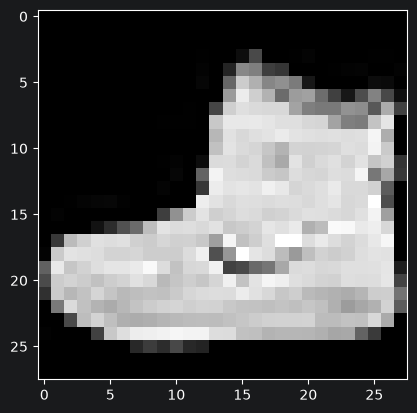

In [2]:
plt.imshow(img1.squeeze(), cmap='gray')

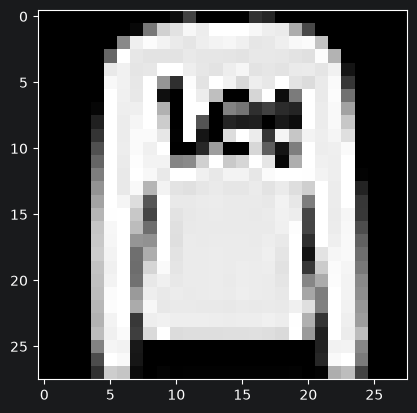

In [3]:
plt.imshow(img2.squeeze(), cmap='gray')

In [4]:
len(train_data)

60000

### Dataloaders

In [5]:
train_dataloader = DataLoader(train_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=False)

### NNModule

In [6]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

### Training loop

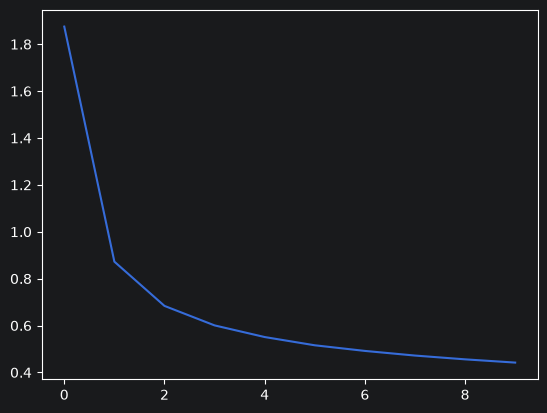

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Model().to(device)

criterion = CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)
loss_history = []
model.train()
for epoch in range(10):
    running_loss = 0
    for X, y in train_dataloader:
        X, y = X.to(device), y.to(device)
        logits = model(X)
        loss = criterion(logits, y)
        running_loss += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    loss_history.append(running_loss / len(train_dataloader))

plt.plot(loss_history)

### Model evaluation

In [8]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for X, y in test_dataloader:
        X, y = X.to(device), y.to(device)
        logits = model(X)
        predictions = logits.argmax(dim=1)
        correct += (predictions == y).sum().item()
        total += len(y)

(correct / total) * 100

83.15

In [13]:
def train_model(lr):
    wandb.init(
        project="fashion_mnist",
        name=f"{lr}",
        config={'lr': lr, "epochs": 10, "batch_size": 64}
    )
    model = Model().to(device)
    criterion = CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)

    model.train()
    for epoch in range(10):
        model.train()
        running_loss = 0
        for X, y in train_dataloader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            loss = criterion(logits, y)
            running_loss += loss.item()
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        avg_loss = running_loss / len(train_dataloader)

        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for X, y in test_dataloader:
                X, y = X.to(device), y.to(device)
                logits = model(X)
                predictions = logits.argmax(dim=1)
                correct += (predictions == y).sum().item()
                total += len(y)
        accuracy = (correct / total) * 100

        wandb.log({"loss": avg_loss, "accuracy": accuracy, "epoch": epoch})
    wandb.finish()

for lr in [0.1, 0.01, 0.001]:
    train_model(lr)

wandb: setting up run wk2grgmy
wandb: Tracking run with wandb version 0.28.2
wandb: Run data is saved locally in C:\Users\kubak\Documents\Programming\PycharmProjects\MachineLearning\FashionMNIST-MLP\wandb\run-20260825_163727-wk2grgmy
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run run_name
wandb:  View project at https://wandb.ai/jacob_21-agh-univeristy-of-krakow/fashion_mnist
wandb:  View run at https://wandb.ai/jacob_21-agh-univeristy-of-krakow/fashion_mnist/runs/wk2grgmy


KeyboardInterrupt: 

### Dropout and weight decay

In [19]:
train_subset = torch.utils.data.Subset(train_data, range(1000))
train_subset_dataloader = DataLoader(train_subset, batch_size=64, shuffle=True)

def train_overfit_demo(lr, run_name):
    wandb.init(
        project="fashion_mnist",
        name=run_name,
        config={'lr': lr, "epochs": 50, "batch_size": 64}
    )
    model = Model().to(device)
    criterion = CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=1e-4)

    model.train()
    for epoch in range(50):
        model.train()
        running_loss = 0
        for X, y in train_subset_dataloader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            loss = criterion(logits, y)
            running_loss += loss.item()
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        avg_loss = running_loss / len(train_subset_dataloader)

        model.eval()
        correct_v1 = 0
        total_v1 = 0
        with torch.no_grad():
            for X, y in train_subset_dataloader:
                X, y = X.to(device), y.to(device)
                logits = model(X)
                predictions = logits.argmax(dim=1)
                correct_v1 += (predictions == y).sum().item()
                total_v1 += len(y)
        accuracy_v1 = (correct_v1 / total_v1) * 100

        correct_v2 = 0
        total_v2 = 0
        running_test_loss = 0
        with torch.no_grad():
            for X, y in test_dataloader:
                X, y = X.to(device), y.to(device)
                logits = model(X)
                loss = criterion(logits, y)
                running_test_loss += loss.item()
                predictions = logits.argmax(dim=1)
                correct_v2 += (predictions == y).sum().item()
                total_v2 += len(y)
        accuracy_v2 = (correct_v2 / total_v2) * 100
        test_loss = running_test_loss / len(test_dataloader)

        wandb.log({"train_loss": avg_loss, "train_accuracy": accuracy_v1, "test_loss": test_loss, "test_accuracy": accuracy_v2, "epoch": epoch})
    wandb.finish()

train_overfit_demo(0.1, "regularized")

wandb: setting up run w387h3nk
wandb: Tracking run with wandb version 0.28.2
wandb: Run data is saved locally in C:\Users\kubak\Documents\Programming\PycharmProjects\MachineLearning\FashionMNIST-MLP\wandb\run-20260825_165000-w387h3nk
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run regularized
wandb:  View project at https://wandb.ai/jacob_21-agh-univeristy-of-krakow/fashion_mnist
wandb:  View run at https://wandb.ai/jacob_21-agh-univeristy-of-krakow/fashion_mnist/runs/w387h3nk
wandb: updating run metadata
wandb: 
wandb: Run history:
wandb:          epoch ▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
wandb:  test_accuracy ▁▂▄▄▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇█▇██████▇▆▇████▇▇███
wandb:      test_loss ██▇▅▄▃▃▃▃▃▄▃▂▂▂▁▂▂▁▃▁▁▂▁▁▁▁▁▁▃▂▁▁▁▁▂▂▁▁▁
wandb: train_accuracy ▁▂▄▃▄▅▆▅▆▆▆▇▇▇▆▆▆▇▆▇▇█▇▇▇████▇█▇███▇█▇██
wandb:     train_loss ██▇▆▅▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb: 
wandb: Run summary:
wandb:          epoch 49
wandb:  test_accuracy 76.8
wandb:      test_loss 0.68024
wandb: train_accu